In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [2]:
df_train = pd.read_csv("./data/raw/playground-series-s6e4/train.csv")
df_test = pd.read_csv("./data/raw/playground-series-s6e4/test.csv")
df_test['Irrigation_Need'] = "Low"
df = pd.concat([df_train,df_test], sort=False)

In [3]:
df['Irrigation_Need'] = df['Irrigation_Need'].map({"Low": 0, "Medium": 1, "High":2})
df['Irrigation_Need'].head()

0    0
1    0
2    0
3    1
4    0
Name: Irrigation_Need, dtype: int64

In [4]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,0
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,0
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,0
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,1
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 900000 entries, 0 to 269999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       900000 non-null  int64  
 1   Soil_Type                900000 non-null  str    
 2   Soil_pH                  900000 non-null  float64
 3   Soil_Moisture            900000 non-null  float64
 4   Organic_Carbon           900000 non-null  float64
 5   Electrical_Conductivity  900000 non-null  float64
 6   Temperature_C            900000 non-null  float64
 7   Humidity                 900000 non-null  float64
 8   Rainfall_mm              900000 non-null  float64
 9   Sunlight_Hours           900000 non-null  float64
 10  Wind_Speed_kmh           900000 non-null  float64
 11  Crop_Type                900000 non-null  str    
 12  Crop_Growth_Stage        900000 non-null  str    
 13  Season                   900000 non-null  str    
 14  Irrigation_Type     

In [7]:
categorial_features = df.select_dtypes(include=['object','str']).columns
categorial_features

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='str')

In [8]:
for col in categorial_features:
    print(f"{col} - {df[col].nunique()}")

Soil_Type - 4
Crop_Type - 6
Crop_Growth_Stage - 4
Season - 3
Irrigation_Type - 4
Water_Source - 4
Mulching_Used - 2
Region - 5


In [9]:
for col in categorial_features:
    
    df_grouped = df.groupby([col, 'Irrigation_Need']).size().reset_index(name='Contagem')
    
    fig = px.bar(df_grouped, 
                 x=col, 
                 y='Contagem', 
                 color='Irrigation_Need', 
                 barmode='group',
                 title=f'Contagem de {col} por Necessidade de Irrigação')
    fig.show()

In [10]:
numerical_features = df.select_dtypes(include=['number']).columns
numerical_features

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm', 'Irrigation_Need'],
      dtype='str')

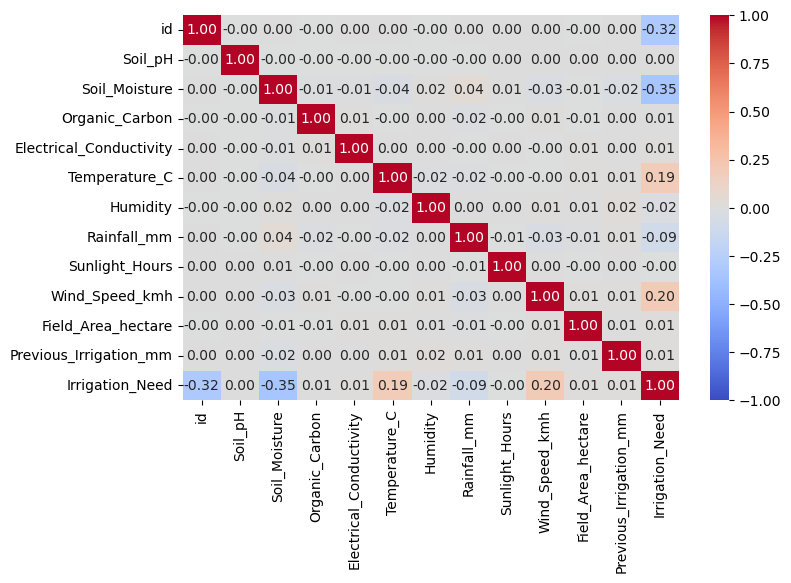

In [11]:
plt.figure(figsize=(8,5))
corr_matrix = df[numerical_features].corr()

sns.heatmap(corr_matrix,vmin=-1,vmax=1,annot=True,cmap='coolwarm', fmt=".2f")
plt.show()

In [12]:
df[numerical_features].corr()['Irrigation_Need'].sort_values(ascending=False)

Irrigation_Need            1.000000
Wind_Speed_kmh             0.197687
Temperature_C              0.193792
Previous_Irrigation_mm     0.014859
Field_Area_hectare         0.013987
Electrical_Conductivity    0.008149
Organic_Carbon             0.005237
Soil_pH                    0.000427
Sunlight_Hours            -0.000230
Humidity                  -0.016294
Rainfall_mm               -0.086200
id                        -0.317866
Soil_Moisture             -0.349339
Name: Irrigation_Need, dtype: float64

In [13]:
for col in numerical_features:
    print(f'{col} - {df[col].isnull().sum()}')

id - 0
Soil_pH - 0
Soil_Moisture - 0
Organic_Carbon - 0
Electrical_Conductivity - 0
Temperature_C - 0
Humidity - 0
Rainfall_mm - 0
Sunlight_Hours - 0
Wind_Speed_kmh - 0
Field_Area_hectare - 0
Previous_Irrigation_mm - 0
Irrigation_Need - 0


In [3]:
df_train = df[:df_train.shape[0]]
df_test = df[df_train.shape[0]:]
df_test.drop(columns=['Irrigation_Need'],inplace=True)

In [4]:
X = df_train.drop(columns=["id", "Irrigation_Need"]).copy()
y = df_train["Irrigation_Need"].copy()

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=0, shuffle=True,stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=0, shuffle=True,stratify=y_temp
)

In [6]:
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorial_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

In [7]:
le = LabelEncoder()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorial_features),
    ],
    remainder="drop"
)


X_train_processed = preprocess.fit_transform(X_train)
X_valid_processed = preprocess.transform(X_valid)
X_test_processed = preprocess.transform(X_test)

y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc  = le.transform(y_test)

In [8]:
print(X_train_processed.shape, X_valid_processed.shape, X_test_processed.shape)

(441000, 43) (94500, 43) (94500, 43)


In [13]:
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.005,
    max_depth=6,
    random_state=0,
    early_stopping_rounds=5,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score 
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train_enc)):
    print(f"Treinando Fold {fold + 1}...")
    
    X_train_fold = X_train_processed[train_idx]
    y_train_fold = y_train_enc[train_idx]
    
    X_val_fold = X_train_processed[val_idx]
    y_val_fold = y_train_enc[val_idx]
    
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False 
    )
    
    y_pred = model.predict(X_val_fold)
    score = accuracy_score(y_val_fold, y_pred)
    scores.append(score)
    
print(f"\nScore médio do CV: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Treinando Fold 1...
Treinando Fold 2...
Treinando Fold 3...
Treinando Fold 4...
Treinando Fold 5...

Score médio do CV: 0.9836 (+/- 0.0002)


In [ ]:
preds = model.predict(X_test_processed)

In [ ]:
print(classification_report(preds,y_test_enc))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56120
           1       0.97      0.98      0.98     35424
           2       0.90      0.96      0.93      2956

    accuracy                           0.98     94500
   macro avg       0.96      0.98      0.97     94500
weighted avg       0.98      0.98      0.98     94500



In [ ]:
X_sub = df_test.drop(columns=["id"]).copy()
ids_sub = df_test["id"].copy()

X_sub_processed = preprocess.transform(X_sub)

preds_sub = model.predict(X_sub_processed)
pred_sub = le.inverse_transform(preds_sub)

sub = pd.DataFrame({
    "id": ids_sub,
    "Irrigation_Need": pred_sub
})
sub.to_csv("submission.csv", index=False)